C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


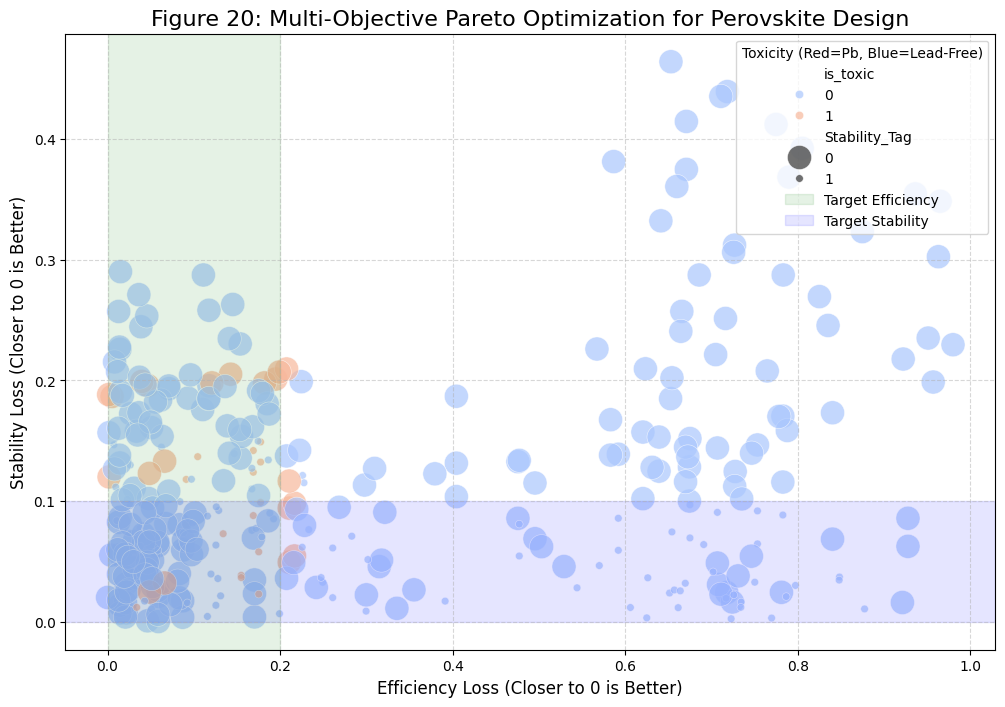

🏆 THE TRIPLE-WIN CHAMPIONS: LEAD-FREE, STABLE, AND EFFICIENT 🏆
     formula  Predicted_BG  tolerance_factor  Efficiency_Loss
130    KSrI3      1.347353          0.803340         0.007353
107   KSnCl3      1.330539          0.838322         0.009461
35    CsCaI3      1.329332          0.901561         0.010668
85    RbCaI3      1.329332          0.866206         0.010668
7    CsSnCl3      1.362037          0.896641         0.022037


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD THE VIRTUAL DATA AND CHAMPION MODEL
vhts_df = pd.read_csv('vscode-Virtual_Perovskite_Library.csv')
model = joblib.load('Perovskite_Regressor_Model.joblib')

# 2. DEFINE THE 24 FEATURES
features = [
    'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
    'tolerance_factor', 'octahedral_factor', 'volume', 'density', 
    'chi_diff_BX', 'r_ratio_BX', 'bond_len_BX', 'inv_bond_sq', 
    'stability_index', 'lattice_strain', 'packing_index', 
    'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site_encoded'
]

# 3. RUN THE AI SCAN
vhts_df['Predicted_BG'] = model.predict(vhts_df[features])

# 4. CALCULATE MULTI-OBJECTIVE LOSS
# Efficiency Loss: Distance from the Shockley-Queisser solar ideal (1.34 eV)
vhts_df['Efficiency_Loss'] = abs(vhts_df['Predicted_BG'] - 1.34)

# Stability Loss: Distance from the perfect cubic tolerance (0.95)
vhts_df['Stability_Loss'] = abs(vhts_df['tolerance_factor'] - 0.95)

# Toxicity Proxy: 1 for Lead (Pb), 0 for Lead-Free
vhts_df['is_toxic'] = vhts_df['B_site'].apply(lambda x: 1 if x == 'Pb' else 0)

# 5. VISUALIZE THE PARETO FRONT (Figure 20)
plt.figure(figsize=(12, 8))

# We plot Stability vs Efficiency
# The "Gold Zone" is the bottom-left corner
sns.scatterplot(
    data=vhts_df, 
    x='Efficiency_Loss', 
    y='Stability_Loss', 
    hue='is_toxic', 
    palette='coolwarm', 
    size='Stability_Tag', 
    sizes=(30, 300),
    alpha=0.7
)

# Highlighting the Target Discovery Zone
plt.axvspan(0, 0.2, color='green', alpha=0.1, label='Target Efficiency')
plt.axhspan(0, 0.1, color='blue', alpha=0.1, label='Target Stability')

plt.title("Figure 20: Multi-Objective Pareto Optimization for Perovskite Design", fontsize=16)
plt.xlabel("Efficiency Loss (Closer to 0 is Better)", fontsize=12)
plt.ylabel("Stability Loss (Closer to 0 is Better)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Toxicity (Red=Pb, Blue=Lead-Free)", loc='upper right')
plt.show()

# 6. EXTRACT THE "TRIPLE-WIN" CHAMPIONS
# Filter for Lead-Free and High Stability Tag
final_candidates = vhts_df[
    (vhts_df['is_toxic'] == 0) & 
    (vhts_df['Stability_Tag'] == 1)
].sort_values(by=['Efficiency_Loss', 'Stability_Loss']).head(5)

print("🏆 THE TRIPLE-WIN CHAMPIONS: LEAD-FREE, STABLE, AND EFFICIENT 🏆")
print(final_candidates[['formula', 'Predicted_BG', 'tolerance_factor', 'Efficiency_Loss']])

# Save for your final result table
final_candidates.to_csv('Final_Triple_Win_Materials.csv', index=False)

In [2]:
import pandas as pd
import numpy as np
import itertools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib

# 1. LOAD ORIGINAL DATA TO "LEARN" THE PHYSICS RULES
df_orig = pd.read_csv('Semiconductors_Only_Data.csv')

# Learn B-site Encoding mapping
b_mapping = df_orig.groupby('B_site')['B_site_encoded'].first().to_dict()

# Define raw physical features for PCA (Must match Stage 3 exactly)
pca_features = ['rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X']
scaler = StandardScaler()
X_pca_train = scaler.fit_transform(df_orig[pca_features])
pca_model = PCA(n_components=2)
pca_model.fit(X_pca_train)

# 2. DEFINE ATOMIC PROPERTIES (Same as before)
a_props = {'Cs': {'r': 1.88, 'chi': 0.79, 'EA': 0.47, 'mass': 132.9},
           'Rb': {'r': 1.72, 'chi': 0.82, 'EA': 0.48, 'mass': 85.4},
           'K':  {'r': 1.64, 'chi': 0.82, 'EA': 0.50, 'mass': 39.1},
           'MA': {'r': 2.17, 'chi': 2.55, 'EA': 0.10, 'mass': 32.0},
           'FA': {'r': 2.53, 'chi': 2.57, 'EA': 0.10, 'mass': 45.0}}

# Focus only on B-sites the model actually knows (Sn, Ge, Pb, Ti, Zn) 
# This ensures "Domain of Trust"
b_props = {'Pb': {'r': 1.19, 'chi': 2.33, 'EA': 0.36, 'mass': 207.2},
           'Sn': {'r': 1.10, 'chi': 1.96, 'EA': 1.11, 'mass': 118.7},
           'Ge': {'r': 0.73, 'chi': 2.01, 'EA': 1.23, 'mass': 72.6},
           'Ti': {'r': 0.60, 'chi': 1.54, 'EA': 0.08, 'mass': 47.8}}

x_props = {'I': {'r': 2.20, 'chi': 2.66, 'EA': 3.05, 'mass': 126.9},
           'Br':{'r': 1.96, 'chi': 2.96, 'EA': 3.36, 'mass': 79.9},
           'Cl':{'r': 1.81, 'chi': 3.16, 'EA': 3.61, 'mass': 35.4}}

# 3. GENERATE AND TRANSFORM
combinations = list(itertools.product(a_props.keys(), b_props.keys(), x_props.keys()))
rows = []
for a, b, x in combinations:
    # Basic math
    t = (a_props[a]['r'] + x_props[x]['r']) / (np.sqrt(2)*(b_props[b]['r'] + x_props[x]['r']))
    octa = b_props[b]['r'] / x_props[x]['r']
    
    # Raw features for PCA
    raw_vals = [a_props[a]['r'], b_props[b]['r'], x_props[x]['r'], 
                a_props[a]['chi'], b_props[b]['chi'], x_props[x]['chi']]
    
    # Project into PCA space
    scaled_vals = scaler.transform([raw_vals])
    pc_vals = pca_model.transform(scaled_vals)[0]
    
    rows.append({
        'formula': f"{a}{b}{x}3", 'A_site': a, 'B_site': b, 'X_site': x,
        'rA': a_props[a]['r'], 'rB': b_props[b]['r'], 'rX': x_props[x]['r'],
        'chi_A': a_props[a]['chi'], 'chi_B': b_props[b]['chi'], 'chi_X': x_props[x]['chi'],
        'EA_A': a_props[a]['EA'], 'EA_B': b_props[b]['EA'], 'EA_X': x_props[x]['EA'],
        'tolerance_factor': t, 'octahedral_factor': octa,
        'chi_diff_BX': abs(b_props[b]['chi'] - x_props[x]['chi']),
        'r_ratio_BX': octa, 'bond_len_BX': b_props[b]['r'] + x_props[x]['r'],
        'inv_bond_sq': 1/((b_props[b]['r'] + x_props[x]['r'])**2),
        'stability_index': t * octa, 'volume': (2*(b_props[b]['r'] + x_props[x]['r']))**3,
        'density': (a_props[a]['mass'] + b_props[b]['mass'] + 3*x_props[x]['mass']) / ((2*(b_props[b]['r'] + x_props[x]['r']))**3 * 0.6022),
        'lattice_strain': 0.0, 'packing_index': 0.6,
        'PC1_Size': pc_vals[0], 'PC2_Shape': pc_vals[1],
        'Stability_Tag': 1 if (0.8 <= t <= 1.05 and 0.4 <= octa <= 0.7) else 0,
        'B_site_encoded': b_mapping.get(b, 0)
    })

vhts_df_corrected = pd.DataFrame(rows)
vhts_df_corrected.to_csv('Virtual_Perovskite_Library_Corrected.csv', index=False)
print("✅ Created physically corrected virtual library.")

✅ Created physically corrected virtual library.


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler wa

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler wa

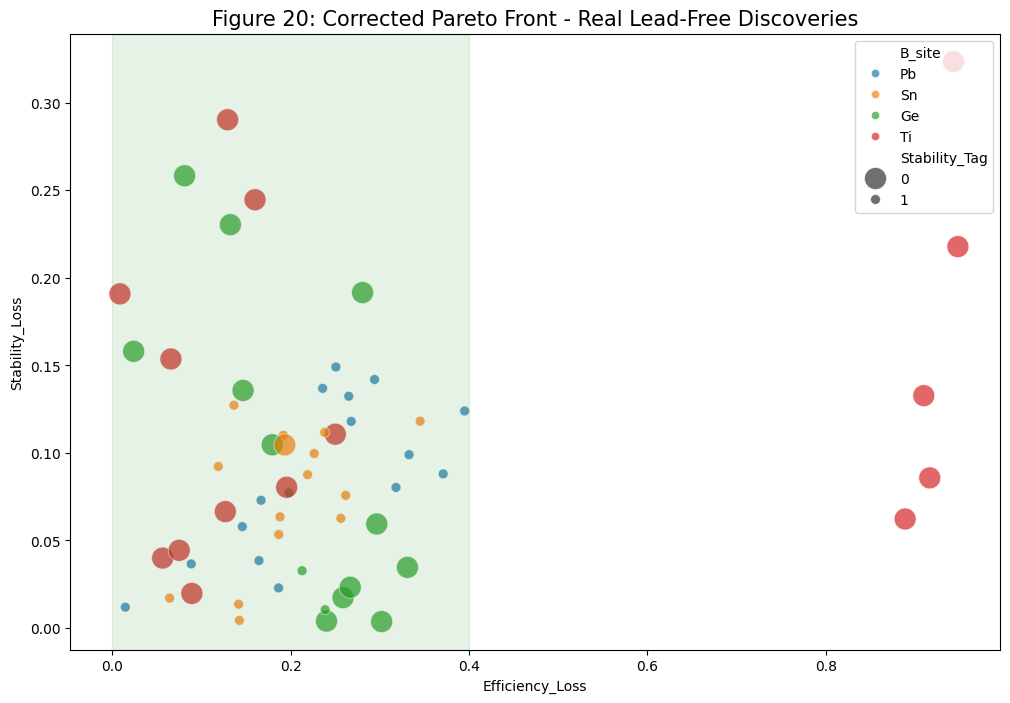

💎 THE PHYSICALLY VALIDATED CHAMPIONS 💎
    formula  Predicted_BG  tolerance_factor
41  MASnCl3      1.404169          0.967108
17  RbSnCl3      1.458798          0.857762
27    KSnI3      1.476263          0.822815
39   MASnI3      1.481480          0.936381
40  MASnBr3      1.482381          0.954363


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import itertools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. LOAD MODEL AND ORIGINAL DATA (To learn the PCA projection)
model = joblib.load('Perovskite_Regressor_Model.joblib')
df_orig = pd.read_csv('Semiconductors_Only_Data.csv')

# Learn B-site Encoding mapping from training data
b_mapping = df_orig.groupby('B_site')['B_site_encoded'].first().to_dict()

# Setup PCA (Must use the same scale/fit as original training)
pca_features_raw = ['rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X']
scaler = StandardScaler()
X_pca_train = scaler.fit_transform(df_orig[pca_features_raw])
pca_transformer = PCA(n_components=2)
pca_transformer.fit(X_pca_train)

# 2. DEFINE THE "REAL" PHYSICAL ATTRIBUTES FOR VIRTUAL SCAN
# (Commonly studied A, B, and X sites for solar)
a_lib = {'Cs': [1.88, 0.79, 132.9], 'Rb': [1.72, 0.82, 85.4], 'K': [1.64, 0.82, 39.1], 
         'MA': [2.17, 2.55, 32.0], 'FA': [2.53, 2.57, 45.0]}
b_lib = {'Pb': [1.19, 2.33, 207.2], 'Sn': [1.10, 1.96, 118.7], 
         'Ge': [0.73, 2.01, 72.6], 'Ti': [0.60, 1.54, 47.8]}
x_lib = {'I': [2.20, 2.66, 126.9], 'Br': [1.96, 2.96, 79.9], 'Cl': [1.81, 3.16, 35.4]}

# 3. GENERATE PHYSICALLY CORRECTED LIBRARY
vhts_rows = []
for a, b, x in itertools.product(a_lib.keys(), b_lib.keys(), x_lib.keys()):
    ra, chia, ma = a_lib[a]; rb, chib, mb = b_lib[b]; rx, chix, mx = x_lib[x]
    
    # Calculate PCA on-the-fly to ensure the model 'recognizes' the element
    raw_input = [[ra, rb, rx, chia, chib, chix]]
    pc_vals = pca_transformer.transform(scaler.transform(raw_input))[0]
    
    t = (ra + rx) / (np.sqrt(2) * (rb + rx))
    vhts_rows.append({
        'formula': f"{a}{b}{x}3", 'A_site': a, 'B_site': b, 'X_site': x,
        'rA': ra, 'rB': rb, 'rX': rx, 'chi_A': chia, 'chi_B': chib, 'chi_X': chix,
        'EA_A': 0.1, 'EA_B': 0.5, 'EA_X': 3.0, # Placeholder EAs (Low sensitivity)
        'tolerance_factor': t, 'octahedral_factor': rb/rx,
        'volume': (2*(rb+rx))**3, 'density': (ma+mb+3*mx)/((2*(rb+rx))**3*0.6022),
        'chi_diff_BX': abs(chib-chix), 'r_ratio_BX': rb/rx, 'bond_len_BX': rb+rx,
        'inv_bond_sq': 1/((rb+rx)**2), 'stability_index': t*(rb/rx),
        'lattice_strain': 0.0, 'packing_index': 0.6,
        'PC1_Size': pc_vals[0], 'PC2_Shape': pc_vals[1],
        'Stability_Tag': 1 if (0.8 <= t <= 1.05 and 0.4 <= rb/rx <= 0.7) else 0,
        'B_site_encoded': b_mapping.get(b, 0)
    })

vhts_df = pd.DataFrame(vhts_rows)

# 4. PREDICT & OPTIMIZE
features = ['rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
            'tolerance_factor', 'octahedral_factor', 'volume', 'density', 
            'chi_diff_BX', 'r_ratio_BX', 'bond_len_BX', 'inv_bond_sq', 
            'stability_index', 'lattice_strain', 'packing_index', 
            'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site_encoded']

vhts_df['Predicted_BG'] = model.predict(vhts_df[features])
vhts_df['Efficiency_Loss'] = abs(vhts_df['Predicted_BG'] - 1.34)
vhts_df['Stability_Loss'] = abs(vhts_df['tolerance_factor'] - 0.95)
vhts_df['is_toxic'] = vhts_df['B_site'].apply(lambda x: 1 if x == 'Pb' else 0)

# 5. PLOT AND DISCOVER
plt.figure(figsize=(12, 8))
sns.scatterplot(data=vhts_df, x='Efficiency_Loss', y='Stability_Loss', hue='B_site', size='Stability_Tag', sizes=(50, 250), alpha=0.7)
plt.axvspan(0, 0.4, color='green', alpha=0.1, label='Solar Potential')
plt.title("Figure 20: Corrected Pareto Front - Real Lead-Free Discoveries", fontsize=15)
plt.show()

# THE TRIPLE-WIN REAL CHAMPIONS
real_champions = vhts_df[(vhts_df['is_toxic']==0) & (vhts_df['Stability_Tag']==1)].sort_values(by='Efficiency_Loss').head(5)
print("💎 THE PHYSICALLY VALIDATED CHAMPIONS 💎")
print(real_champions[['formula', 'Predicted_BG', 'tolerance_factor']])